In [1]:
import os
os.chdir('..')

In [2]:
import pm4py
import pickle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pm4py.algo.analysis.woflan import algorithm as woflan
from pm4py.objects.petri_net.utils import reachability_graph
from pm4py.visualization.transition_system import visualizer as ts_visualizer

------ Iteration 0 ------


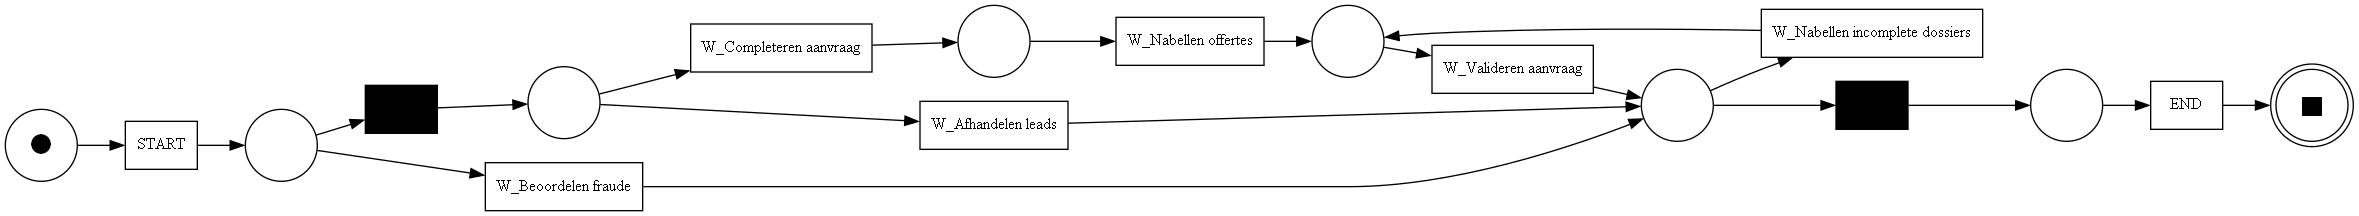

Net is sound.



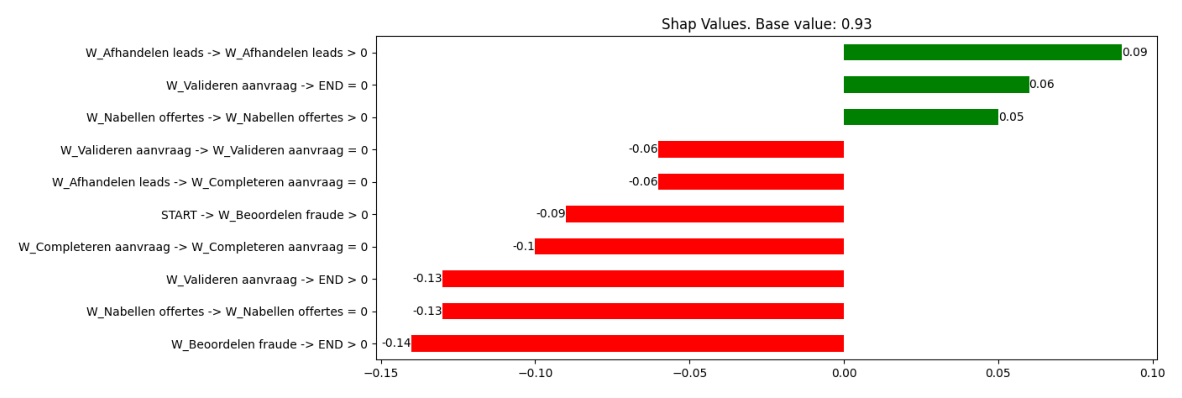

W_Completeren aanvraag -> W_Completeren aanvraag :  skip
W_Afhandelen leads -> W_Afhandelen leads :  skip
START -> W_Beoordelen fraude :  skip_b
W_Afhandelen leads -> W_Completeren aanvraag :  skip
W_Valideren aanvraag -> W_Valideren aanvraag :  skip
W_Nabellen offertes -> W_Nabellen offertes :  skip



------ Iteration 1 ------


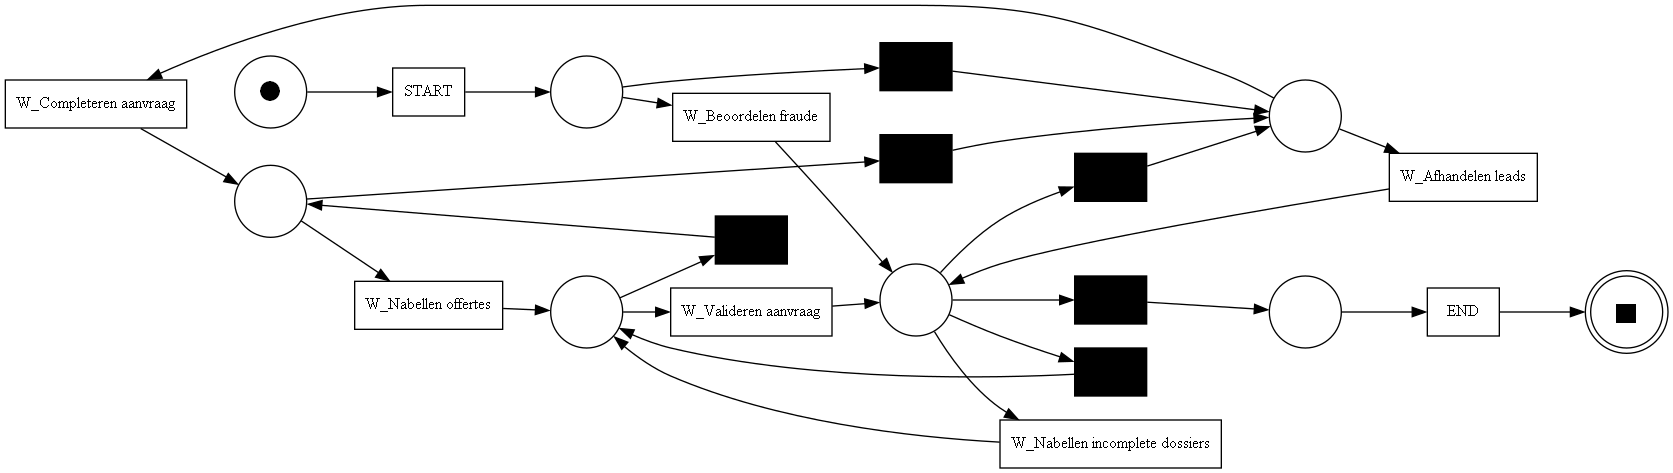

Net is sound.



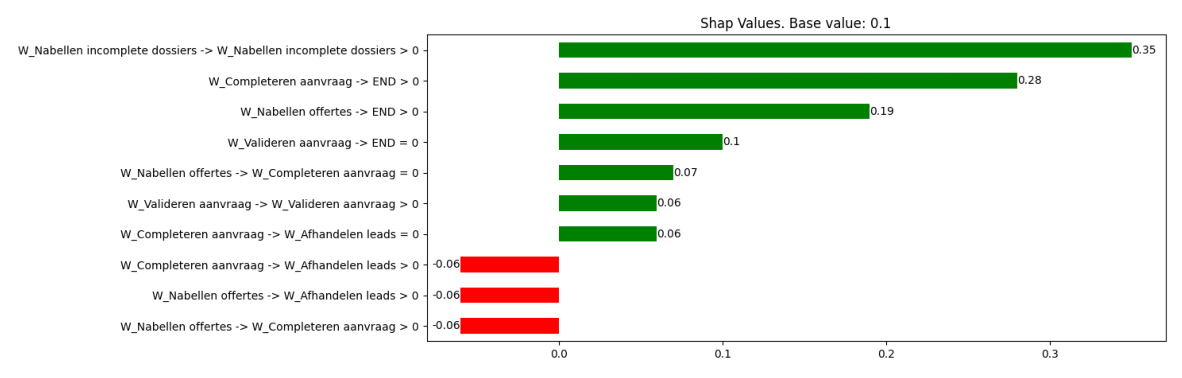

W_Nabellen incomplete dossiers -> W_Nabellen incomplete dossiers :  skip
W_Completeren aanvraag -> END :  skip
W_Nabellen offertes -> END :  skip
W_Valideren aanvraag -> W_Valideren aanvraag :  skip
W_Nabellen offertes -> W_Completeren aanvraag :  skip_b
W_Nabellen offertes -> W_Afhandelen leads :  skip_b
W_Completeren aanvraag -> W_Afhandelen leads :  skip_b



------ Iteration 2 ------


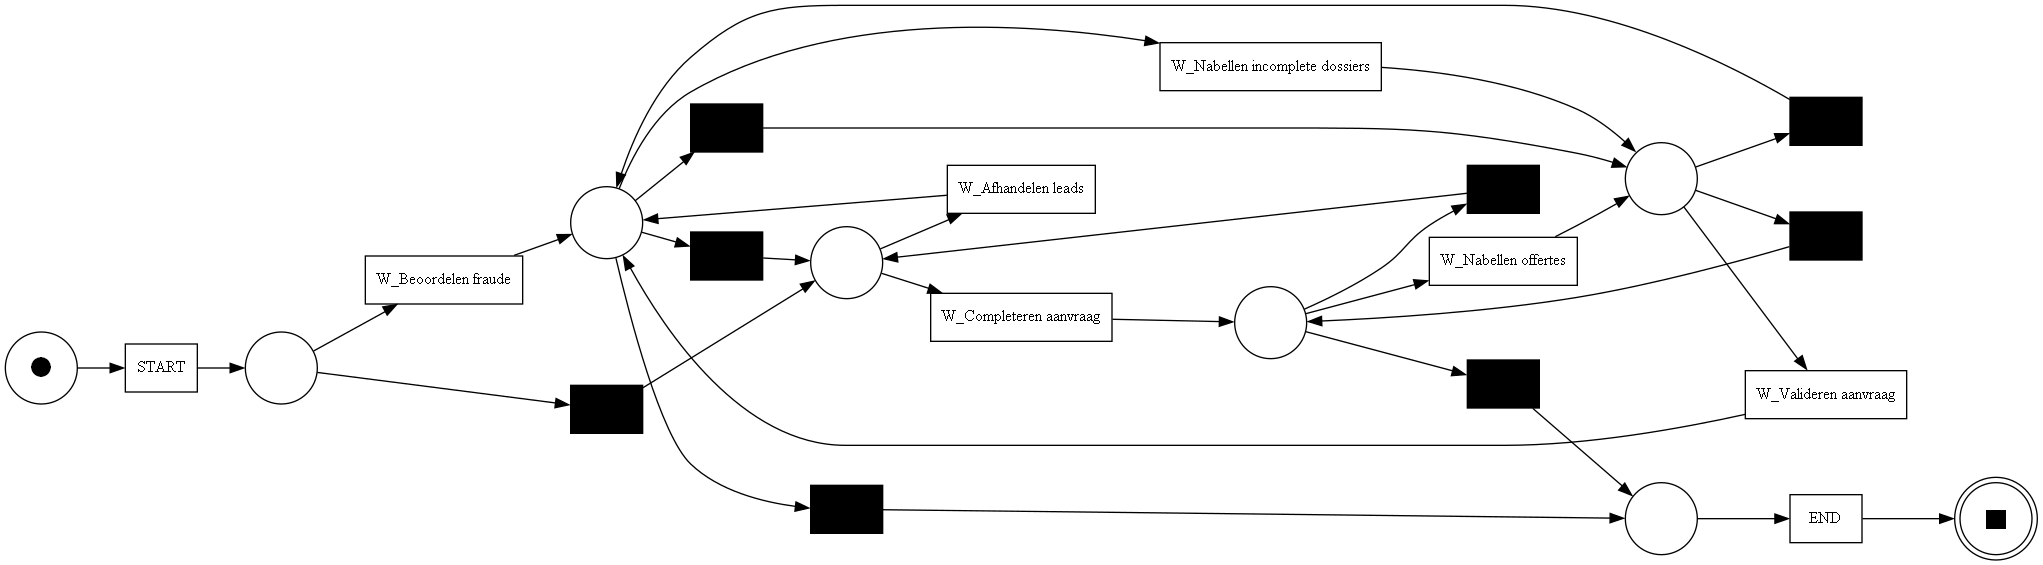

Net is sound.



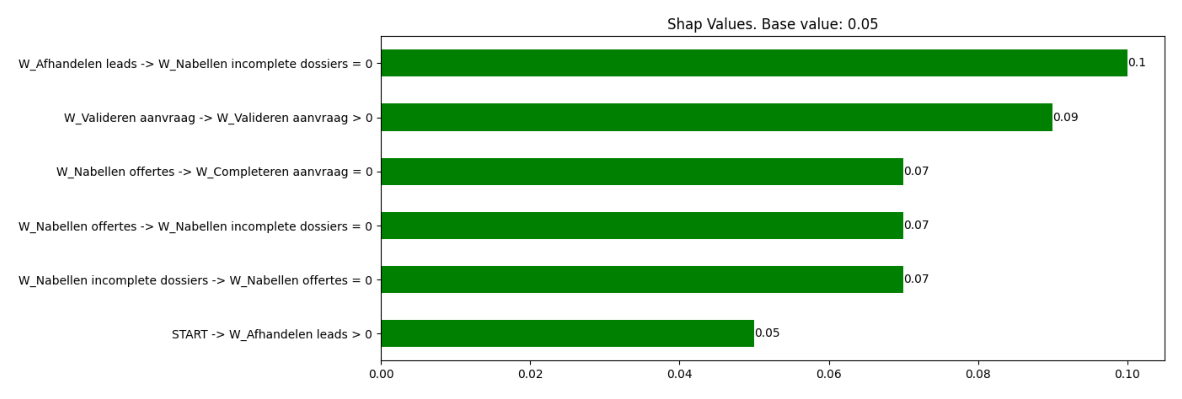

W_Afhandelen leads -> W_Nabellen incomplete dossiers :  skip_b
W_Valideren aanvraag -> W_Valideren aanvraag :  skip
W_Nabellen incomplete dossiers -> W_Nabellen offertes :  skip_b
W_Nabellen offertes -> W_Nabellen incomplete dossiers :  skip_b
W_Nabellen offertes -> W_Completeren aanvraag :  skip_b
START -> W_Afhandelen leads :  skip





In [3]:
case_study = 'BPI12'
n_exp = 2

n_it = len(os.listdir(f'data/{case_study}/exp_{n_exp}')) - 2

for i in range(n_it):
    print(f'------ Iteration {i} ------')
    net, im, fm = pm4py.read_pnml(f'data/{case_study}/exp_{n_exp}/it_{i}/diagram_{i}.pnml')
    pm4py.view_petri_net(net, im, fm)
    is_sound = woflan.apply(net, im, fm, parameters={woflan.Parameters.RETURN_ASAP_WHEN_NOT_SOUND: True,
                                                     woflan.Parameters.PRINT_DIAGNOSTICS: False,
                                                     woflan.Parameters.RETURN_DIAGNOSTICS: False})
    if is_sound:
        print('Net is sound.\n')
    else:
        print('Net is not sound.\n')

    # ts = reachability_graph.construct_reachability_graph(net, im)
    # gviz = ts_visualizer.apply(ts)
    # ts_visualizer.view(gviz)

    plt.figure(figsize=(15, 12))
    shap_plot_img = mpimg.imread(f'plots/{case_study}/exp_{n_exp}/shap_{i}.png')
    plt.imshow(shap_plot_img)
    plt.axis('off')
    plt.show()

    file = open(f'data/{case_study}/exp_{n_exp}/it_{i}/recc_{i}.pickle', 'rb')
    recc = pickle.load(file)
    file.close()
    for r in recc:
        print(r, ': ', recc[r][1])

    print('\n'*2)
    